In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mt 

from sklearn.linear_model import LogisticRegression as logR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


data  = pd.read_csv('StudentData2.csv')

data.drop(columns=['Marks'],inplace=True)
print(data)

data["Pass"] = [0,0,0,0,1,1,1,1,1,1]
print(data)


data.to_csv('StudentData3.csv', index=False)





   Hours  Attendance  Sleep
0      1          60      5
1      2          65      6
2      3          70      6
3      4          75      7
4      5          80      7
5      6          85      8
6      7          90      8
7      8          95      8
8      5          88      7
9      7          92      8
   Hours  Attendance  Sleep  Pass
0      1          60      5     0
1      2          65      6     0
2      3          70      6     0
3      4          75      7     0
4      5          80      7     1
5      6          85      8     1
6      7          90      8     1
7      8          95      8     1
8      5          88      7     1
9      7          92      8     1


In [14]:
X  = data[["Hours","Attendance","Sleep"]]
Y = data["Pass"]

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

model = logR()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)



   Actual  Predicted
8       1          1
1       0          0


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")    
print(classification_report(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred)) 

Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Accuracy: 1.0


In [17]:
print("MSE", mean_squared_error(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("R2 Score", r2_score(y_test, y_pred))

MSE 0.0
MAE 0.0
R2 Score 1.0


In [19]:
new = input("Enter Hours, Attendance, Sleep (comma separated): ")

new = list(map(float, new.split(',')))

if model.predict([new]) == 1: 
    print("The student is likely to pass.")
else:
    print("The student is likely to fail.")

The student is likely to pass.


c:\Users\muhmd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [24]:

student = [6, 85, 7]

pred = model.predict_proba([student])

print(pred)

print(model.predict_proba([[3,70,6]]))
print(model.predict_proba([[6,85,7]]))
print(model.predict_proba([[8,95,8]]))

[[0.00360554 0.99639446]]
[[0.99641743 0.00358257]]
[[0.00360554 0.99639446]]
[[1.99685317e-06 9.99998003e-01]]


c:\Users\muhmd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\muhmd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\muhmd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\muhmd\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


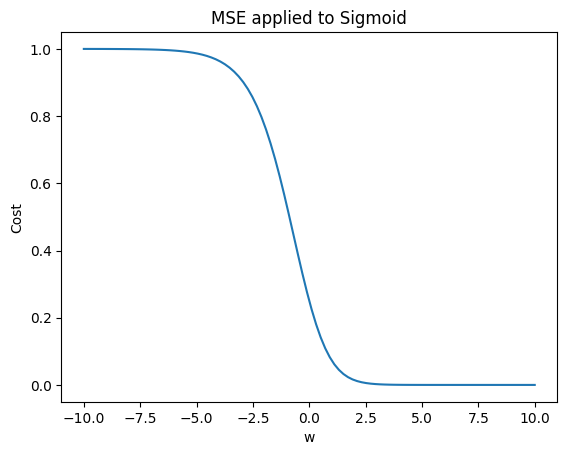

In [26]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-10, 10, 100)

mse_cost = (1/(1+np.exp(-w)) - 1)**2

plt.plot(w, mse_cost)
plt.xlabel("w")
plt.ylabel("Cost")
plt.title("MSE applied to Sigmoid")
plt.show()

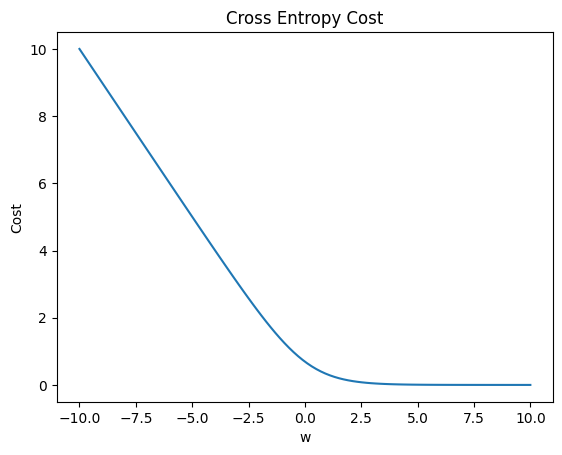

In [28]:
import numpy as np
import matplotlib.pyplot as plt

w = np.linspace(-10, 10, 100)

h = 1/(1+np.exp(-w))

cost = -np.log(h)

plt.plot(w, cost)
plt.xlabel("w")
plt.ylabel("Cost")
plt.title("Cross Entropy Cost")
plt.show()

Epoch=0, Loss=0.6931, w=0.0100, b=0.0000
Epoch=100, Loss=0.5861, w=0.1922, b=-0.1431
Epoch=200, Loss=0.5586, w=0.2237, b=-0.3059
Epoch=300, Loss=0.5335, w=0.2532, b=-0.4614
Epoch=400, Loss=0.5106, w=0.2816, b=-0.6100
Epoch=500, Loss=0.4897, w=0.3089, b=-0.7520
Epoch=600, Loss=0.4706, w=0.3352, b=-0.8878
Epoch=700, Loss=0.4530, w=0.3605, b=-1.0178
Epoch=800, Loss=0.4369, w=0.3848, b=-1.1424
Epoch=900, Loss=0.4220, w=0.4083, b=-1.2619

predicted probabilities:
 [0.27992304 0.37422469 0.47915543 0.58595825 0.68524677 0.77006858
 0.83745421 0.88796442]
[0 0 0 1 1 1 1 1]


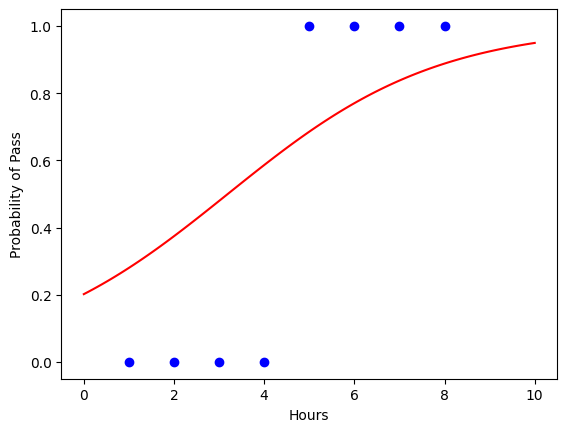

In [43]:
import numpy as np

X = np.array([1,2,3,4,5,6,7,8])
y = np.array([0,0,0,0,1,1,1,1])



def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w = 0
b = 0

learning_rate = 0.01
epochs = 1000
tolerance = 1e-5  # Convergence criterion
patience = 50     # For early stopping

m = len(X)

prev_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):
    
    z = w*X + b
    
    y_hat = sigmoid(z)
    
    
    loss = -(1/m) * np.sum(y*np.log(y_hat+1e-10) + (1-y)*np.log(1-y_hat+1e-10))
    
    #gradients
    dw = (1/m) * np.sum((y_hat - y) * X)
    db = (1/m) * np.sum(y_hat - y)
    
    #update weights and bias
    w = w - learning_rate*dw
    b = b - learning_rate*db
    
    if epoch % 100 == 0:
        print(f"Epoch={epoch}, Loss={loss:.4f}, w={w:.4f}, b={b:.4f}")
    
    # Convergence Criterion 1: Loss change is very small
    if abs(loss - prev_loss) < tolerance:
        print(f"Converged at epoch {epoch}: Loss change ({abs(loss - prev_loss):.2e}) < tolerance ({tolerance})")
        break
    
    # Convergence Criterion 2: Loss stopped improving (early stopping with patience)
    if loss > prev_loss:
        patience_counter += 1
    else:
        patience_counter = 0
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}: No improvement for {patience} epochs")
        break
    
    prev_loss = loss

z2 = w*X + b

y_hat2 = sigmoid(z2)

print("\npredicted probabilities:\n", y_hat2)

preds = (y_hat2 >= 0.5).astype(int)

print(preds)


import matplotlib.pyplot as plt

x_plot = np.linspace(0,10,100)

y_plot = sigmoid(w*x_plot + b)

plt.scatter(X,y,color='blue')
plt.plot(x_plot,y_plot,color='red')

plt.xlabel("Hours")
plt.ylabel("Probability of Pass")

plt.show()